In [1]:

# Common imports
import matplotlib.pyplot as plt
import numpy as np


import scipy.constants as const
import numpy as np
from scipy.linalg import eigh
import matplotlib as mpl

from matplotlib.transforms import Bbox
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


## Constants and calibrational data

In [2]:
# ------------------ Physical constants ------------------
Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1
Delta_Al = 3.4e-4*e # J

# ------------------ System parameters ------------------
T = 15e-3 #K
Ec= 0.233e9*h #JAC
C = e**2/(2*Ec) #F

Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm^2


## Hamiltonian construction

In [3]:

def build_phase_hamiltonians(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        ng: float,
) -> np.ndarray:

    """
    Construct phase-basis Hamiltonians for a superconducting circuit.
    """
    # ----------------- Phase grid -----------------
    phis = phis * 2*np.pi
    N = len(phis)
    delta_phi = phis[1] - phis[0]

    # ----------------- Differential operators -----------------
        # First derivative
    D1 = np.eye(N,k=1) - np.eye(N,k=-1)
    D1[0,-1] = -1
    D1[-1,0] = 1
    D1 /= (2*delta_phi)

    # Second derivative (Laplacian)
    D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
    D2[0,-1] = D2[-1,0] = 1
    D2 /= delta_phi**2

    # ----------------- Kinetic term -----------------
    T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
    
    # ----------------- Effective left arm SQUID parameters -----------------
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    EJsum = EJ4 + EJ5

    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

    # Transmission coefficients (clipped for stability)
    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t1 = np.clip(t1, 0.0, 1.0)

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    t2 = np.clip(t2, 0.0, 1.0)

    # ----------------- Capacitances & charging energies for internal modes -----------------

    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)
    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9

    C_mod_R = CJ3 + CJ45
    EC_mod_R = e**2/(2*C_mod_R*h)*1e-9

    # ----------------- Energy scales -----------------
    E_L = EJ1 + EJ2
    E_R = EJ3 + EJ45eff

    # ----------------- Grid reshaping -----------------
    phi_grid = phis[None, :]                  # shape (1, N)
    flux1_grid = flux1[:, None] 

    V = np.zeros((len(flux1), N, N), dtype=float)

    # ----------------- Potential energy prefactors -----------------
    PF_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
    PF_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

    PF_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2)
    PF_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2))

    # ----------------- Potential energy -----------------
    V_phi = -(E_L * PF_L + E_R * PF_R)

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])  

    # ----------------- Full Hamiltonian -----------------
    H_all = V + T[None, :, :] 

    return H_all, V_phi, phis


In [4]:
a, b = np.polyfit(jj_area, Ej, 1)

def get_junction_area(Ej):
    area = (Ej-b)/a
    return area

def get_CJ(EJ1):
    C_per_Area = 50e-15 #50 fF/mum^2
    
    area_EJ1 = get_junction_area(EJ1)*1e-6
    CJ1 =  C_per_Area*area_EJ1
    
    return CJ1

## Spectrum computation

In [5]:
def n_operator_phase(N, delta_phi, ng=0.0):
    # central finite difference for derivative
    t = 1 / (2 * delta_phi)
    n_op = np.zeros((N, N), dtype=complex)
    
    # off-diagonal elements
    for i in range(N-1):
        n_op[i, i+1] = -1j * t
        n_op[i+1, i] = 1j * t
    
    # periodic boundary
    n_op[0, -1] = 1j * t
    n_op[-1, 0] = -1j * t
    
    # offset by ng
    n_op -= ng * np.eye(N)
    
    return n_op


In [6]:
def compute_qubit_properties(EJ1, EJ2, EJ3, EJ4, EJ5, flux1, flux2, phi, Ec, ng, n_max=50):
    
    # Build Hamiltonians
    H_all, V_phi, phis = build_phase_hamiltonians(EJ1=EJ1, EJ2=EJ2, EJ3=EJ3,EJ4=EJ4, EJ5=EJ5, flux1=flux1, flux2=flux2, phis=phi, Ec= EC, ng = 0.0)

    N = len(phis)
    # Phase grid

    # Charge operator
    delta_phi = phis[1] - phis[0]
    n_op = n_operator_phase(N, delta_phi)

    
    # -------------- calculating flux and charge matrix element, extracting, qp_noise, f01---------------

    n01_list = []


    for i, H in enumerate(H_all):
        eigvals, evecs = np.linalg.eigh(H)

        n_eigen = evecs.conj().T @ n_op @ evecs
        n01 = n_eigen[0,1]
        n01_mod_sq = np.abs(n01)**2
        n01_list.append(n01_mod_sq)

    return (np.array(n01_list))



In [7]:
def compute_spectrum(flux1_val, flux2_val):
    H_all, V_psi, phis = build_phase_hamiltonians(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
        phis=phi,
        flux1=np.array([flux1_val]),
        flux2=flux2_val,
        Ec=EC, ng=ng,
    )

    H = H_all[0]
    H = (H + H.conj().T) / 2
    evals, evecs = np.linalg.eigh(H)
    evals = np.real(evals)

    phis = phis / (2*np.pi)
    E0 = evals[0]
    evals -= E0
    V = V_psi[0, :] - E0

    return phis, evals, evecs, V


## Potential computation and vizualization

## Visualization

In [8]:
# ------------------ Plot styling ------------------

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})

even_cmap = mpl.colormaps["Oranges"]
odd_cmap  = mpl.colormaps["Purples"]

even_colors = {
    0: even_cmap(0.65),
    2: even_cmap(0.85),
}

odd_colors = {
    1: odd_cmap(0.65),
    3: odd_cmap(0.9),
}

c_Transmon = "#9c334d"
c_cos2phi = "#598D07"

In [9]:
phi_2_datasets = {
    '1': {
        'phi_2': 0.406,
    },
    '2': {
        'phi_2': 0.395,
    },
    '3': {
        'phi_2': 0.378,
    },
    '4': {
        'phi_2': 0.367,

    },
}

In [10]:
def phase_to_charge(psi_phi):
    psi_n = np.fft.fftshift(np.fft.fft(psi_phi))
    psi_n /= np.sqrt(len(psi_phi))
    return psi_n


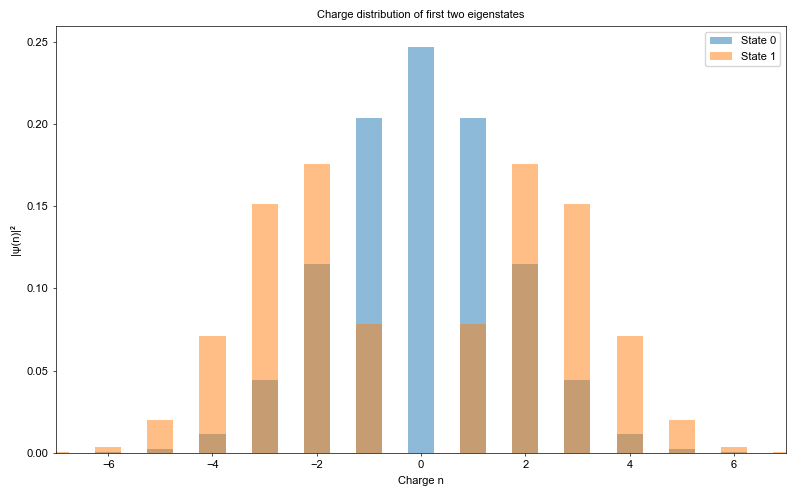

In [11]:

EC = 0.21
EJ1 = 42.49
EJ2 = 53.9
EJ3 = 88.11
EJ4 = 35.73
EJ5 = 35.731
ng = 0.0
n_max = 50



dataset_keys = ['1', '2', '3', '4']

selected = phi_2_datasets['4']

flux2 = selected['phi_2']

flux1= np.linspace(0, 1, 101)  

phi = np.linspace(-0.5, 0.5, 51)

def phase_to_charge(psi_phi):
    psi_n = np.fft.fftshift(np.fft.fft(psi_phi))
    psi_n /= np.sqrt(len(psi_phi))
    return psi_n


H_all, V_phi, phis = build_phase_hamiltonians(
    EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
    flux1=flux1, flux2=flux2, phis=phi,
    Ec=EC, ng=0.0
)

evals, evecs = np.linalg.eigh(H_all[0])


N = len(phi)
dphi = phi[1] - phi[0]

n_vals = np.fft.fftfreq(N, d=dphi)  # raw Fourier modes
n_vals = np.fft.fftshift(n_vals)
n_vals = np.round(n_vals).astype(int)

states = [0, 1]

plt.figure(figsize=(8,5))

for i, s in enumerate(states):
    psi_phi = evecs[:, s]
    psi_n = phase_to_charge(psi_phi)

    prob = np.abs(psi_n)**2
    prob /= np.sum(prob)

    plt.bar(
        n_vals,
        prob,
        alpha=0.5,
        width=0.5,
        label=f"State {s}"
    )

results = {}

plt.xlim(-7, 7)
plt.xlabel("Charge n")
plt.ylabel("|ψ(n)|²")
plt.title("Charge distribution of first two eigenstates")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
results = {}

for key in dataset_keys:
    selected = phi_2_datasets[key]
    flux2 = selected['phi_2']
    # flux_data = selected['flux_data']
    # t1_data = selected['t1_data']
    
    # Compute qubit properties for this dataset
    n01 = compute_qubit_properties(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5 = EJ5,
        flux1=flux1,
        flux2=flux2,
        phi=phi,
        Ec= EC, ng = ng,
        n_max=50
    )

    # Store results
    results[key] = {
        'flux1': flux1,
        'n_op': n01,
        
    }

In [13]:
flux1= np.linspace(0.4, 0.6, 101)

results = {}

for key in dataset_keys:
    selected = phi_2_datasets[key]
    flux2 = selected['phi_2']

    # Build Hamiltonian
    H_all, V_phi, phis = build_phase_hamiltonians(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
        flux1=flux1, flux2=flux2, phis=phi,
        Ec=EC, ng=ng
    )

    # Pick one phi index (same as your example)
    evals, evecs = np.linalg.eigh(H_all[50])

    # FFT setup
    N = len(phi)
    dphi = phi[1] - phi[0]

    n_vals = np.fft.fftfreq(N, d=dphi)
    n_vals = np.fft.fftshift(n_vals)
    n_vals = np.round(n_vals).astype(int)

    states = [0, 1]

    state_data = {}

    for s in states:
        psi_phi = evecs[:, s]
        psi_n = phase_to_charge(psi_phi)

        prob = np.abs(psi_n)**2
        prob /= np.sum(prob)

        # Store per state
        state_data[s] = {
            'n_vals': n_vals.copy(),
            'prob': prob.copy()
        }

    n01 = compute_qubit_properties(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5 = EJ5,
        flux1=flux1,
        flux2=flux2,
        phi=phi,
        Ec= EC, ng = ng,
        n_max=50
    )

    # Store everything per dataset
    results[key] = {
        'flux1': flux1,
        'flux2': flux2,
        'states': state_data, 
        'n_op': n01,
    }

C:\Users\nzhurbina\AppData\Local\Temp\ipykernel_94296\3267702739.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


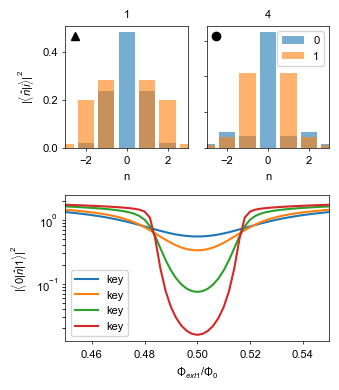

In [14]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})

from matplotlib.lines import Line2D


# Pick your datasets
keys_to_plot = [dataset_keys[0], dataset_keys[3]]
keys_to_plot_mm = [dataset_keys[0], dataset_keys[1],  dataset_keys[2], dataset_keys[3]]

markers = ['^', 'D', 's', 'o']
marker_map = {key: markers[i % len(markers)] for i, key in enumerate(dataset_keys)}

fig = plt.figure(figsize=(3.40457, 4.1))
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1, 1.2],
    hspace=0.35,   # vertical space between rows
    wspace=0.15    # horizontal space between top plots
)

# --- Top row: two bar plots ---
for i, key in enumerate(keys_to_plot):
    ax = fig.add_subplot(gs[0, i])

    marker = marker_map[key]

    ax.plot(
    0.08, 0.92,
    marker=marker_map[key],
    color='black',
    markersize=6,
    linestyle='None',
    transform=ax.transAxes
        )

    for s in [0, 1]:
        n_vals = results[key]['states'][s]['n_vals']
        prob = results[key]['states'][s]['prob']

        ax.bar(
            n_vals,
            prob,
            alpha=0.6,
            width=0.8,
            label=f"{s}"
        )
    if i == 0:
        ax.set_ylabel(r"$|\langle\hat{n}|i\rangle|^2$")   
    else:
        ax.set_ylabel("")                      # remove label
        ax.tick_params(labelleft=False)    
            # optional: hide y tick labels

    marker = marker_map[key]

    ax.set_xlim(-3, 3)  
    ax.set_title(f"{key}")
    ax.set_xlabel("n")
    # ax.set_ylabel("P(n)", fontsize=8)
    ax.tick_params()

    if i == 1:
        ax.legend()


# --- Bottom row: spanning plot ---
ax_bottom = fig.add_subplot(gs[1, :])

for key in keys_to_plot_mm:
    data = results[key]

    ax_bottom.plot(
        data['flux1'],
        data['n_op'],
        linewidth=1.5,
        label=f'key', 
    )



ax_bottom.set_yscale('log')
ax_bottom.set_xlim(0.45, 0.55)
ax_bottom.set_xlabel(r"$\Phi_{ext1}/\Phi_0$")
ax_bottom.set_ylabel(r"$|\langle 0|\hat{n}|1\rangle|^2$")
ax_bottom.tick_params()
ax_bottom.legend()

# --- Layout tuning ---
plt.tight_layout()
plt.show()

C:\Users\nzhurbina\AppData\Local\Temp\ipykernel_94296\1415889173.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


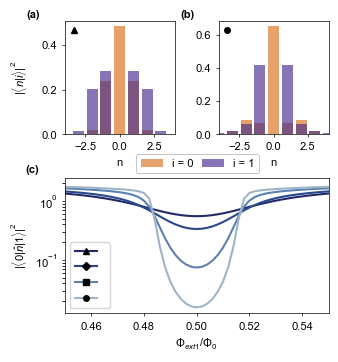

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from itertools import cycle

# ----------------------------
# STYLE
# ----------------------------
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})

# ----------------------------
# DATA SELECTION
# ----------------------------
keys_to_plot = [dataset_keys[0], dataset_keys[3]]
keys_to_plot_mm = dataset_keys[:4]

markers = ['^', 'D', 's', 'o']
colors = ["#232A69", "#28488D", "#5B81B1", '#9FB4C7']
# colors = ["#295734", '#607744', '#768948', '#B39C4D']
# colors = ["#074373", '#9FB4C7', '#1F487E', '#1D3461']
color_map = dict(zip(keys_to_plot_mm, colors))
marker_map = {key: markers[i % len(markers)] for i, key in enumerate(dataset_keys)}
markers = ['^', 'D', 's', 'o']
state_colors = {
    0: "#D86F19",
    1: "#452A8D"
}
marker_map = {key: markers[i % len(markers)] for i, key in enumerate(keys_to_plot_mm)}

# ----------------------------
# FIGURE LAYOUT
# ----------------------------
fig = plt.figure() 
fig.set_size_inches(3.40457, 3.8)
gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[1, 1.2],
    hspace=0.35,
    wspace=0.4
)

# ============================================================
# TOP ROW: BAR PLOTS
# ============================================================
for i, key in enumerate(keys_to_plot):
    ax = fig.add_subplot(gs[0, i])

    label = ['(a)', '(b)'][i]
    ax.text(
        -0.35, 1.1, label,
        transform=ax.transAxes,
        fontweight='bold',
        va='top',
        ha='left'
    )
    # --- marker in corner ---
    ax.plot(
    0.08, 0.92,
    marker=marker_map[key],
    color='black',
    markersize=4,
    linestyle='None',
    transform=ax.transAxes
        )

    # --- bar plots ---
    for s in [0, 1]:
        n_vals = results[key]['states'][s]['n_vals']
        prob = results[key]['states'][s]['prob']

        ax.bar(
            n_vals,
            prob,
            alpha=0.65,
            width=0.8,
            label=f"i = {s}",
            color=state_colors[s]
        )

    # --- axis formatting ---
    ax.set_xlim(-4, 4)
    ax.set_xlabel("n")
    

    if i == 0:
        ax.set_ylabel(r"$|\langle {n}|i\rangle|^2$")
        ax.yaxis.labelpad = 8

    else:
        # ax.legend()
        ax.set_ylabel("")
        ax.tick_params(labelleft=True)
        
        legend =  ax.legend(
        loc='upper left',
        bbox_to_anchor=(-0.75, -0.18),
        ncol=2,
        frameon=True,
        columnspacing=0.8,
        borderaxespad=0,
    )
        legend.get_frame().set_edgecolor('0.7')
        legend.get_frame().set_linewidth(0.6)
        legend.get_frame().set_alpha(0.9)

    ax.tick_params()

# ============================================================
# BOTTOM ROW: LINE PLOT
# ============================================================
ax_bottom = fig.add_subplot(gs[1, :])

# # ----------------------------
# CUSTOM LEGEND (MARKERS ONLY)
# ----------------------------
from itertools import cycle

marker_cycle = cycle(markers)

legend_handles = []

for i, key in enumerate(keys_to_plot_mm):
    data = results[key]
    c = color_map[key]
    m = next(marker_cycle)

    line, = ax_bottom.plot(
        data['flux1'],
        data['n_op'],
        linewidth=1.5,
        label=key, 
        color=c
    )

    legend_handles.append(
        Line2D(
            [],
            [],
            # color=c
            color=line.get_color(),   # line stays colored
            linestyle='-',
            marker=m,
            markerfacecolor='black',   # marker fill
            markeredgecolor='black',   # marker edge
            markersize=4,
            linewidth=1.5,
        
        )
    )

ax_bottom.text(
    -0.15, 1.1, '(c)',
    transform=ax_bottom.transAxes,
    fontweight='bold',
    va='top',
    ha='left'
)

ax_bottom.legend(handles=legend_handles)
ax_bottom.yaxis.labelpad = 3.5
ax_bottom.set_yscale('log')
ax_bottom.set_xlim(0.45, 0.55)
ax_bottom.set_xlabel(r"$\Phi_{ext1}/\Phi_0$")
ax_bottom.set_ylabel(r"$|\langle 0|\hat{n}|1\rangle|^2$")
ax_bottom.tick_params()



fig.savefig("FigS3_Charge_basis.pdf", bbox_inches='tight')
# ----------------------------
plt.tight_layout()
plt.show()